Install dependencies

In [ ]:
# Uses yt-dlp to download from YouTube; falls back to asking you to upload videos if download fails.
!pip install --quiet ftfy regex tqdm
!pip install --quiet git+https://github.com/openai/CLIP.git
!pip install --quiet torch torchvision --extra-index-url https://download.pytorch.org/whl/cpu
!pip install --quiet scikit-learn matplotlib opencv-python yt-dlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.9 MB/s eta 0:00:00


Imports and device setup

In [ ]:
import os, sys, math, io, time, subprocess
from tqdm import tqdm
import numpy as np
import torch
import clip
from PIL import Image
import cv2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from google.colab import files

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cpu


Helper functions for frames, CLIP embedding, downloads

In [ ]:

def extract_frames(video_path, out_dir, fps=1):
    os.makedirs(out_dir, exist_ok=True)
    vidcap = cv2.VideoCapture(video_path)
    if not vidcap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")
    video_fps = vidcap.get(cv2.CAP_PROP_FPS) or 25
    frame_interval = max(1, int(round(video_fps / fps)))
    frames = []
    count = 0
    saved = 0
    success = True
    while success:
        success, image = vidcap.read()
        if not success:
            break
        if count % frame_interval == 0:
            fname = os.path.join(out_dir, f"frame_{saved:04d}.jpg")
            cv2.imwrite(fname, image)
            frames.append(fname)
            saved += 1
        count += 1
    vidcap.release()
    return frames

def load_image_for_clip(path, preprocess):
    image = Image.open(path).convert("RGB")
    return preprocess(image)

def compute_clip_frame_embeddings(frame_paths, model, preprocess, batch_size=16):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(frame_paths), batch_size):
            batch_paths = frame_paths[i:i+batch_size]
            imgs = torch.stack([load_image_for_clip(p, preprocess) for p in batch_paths]).to(device)
            emb = model.encode_image(imgs)  # (B, D)
            emb = emb / emb.norm(dim=-1, keepdim=True)
            embeddings.append(emb.cpu().numpy())
    if embeddings:
        embeddings = np.vstack(embeddings)
    else:
        embeddings = np.zeros((0, model.visual.output_dim if hasattr(model.visual, 'output_dim') else 512))
    return embeddings

def video_level_embedding_from_frames(frame_embeddings, method="mean"):
    if frame_embeddings.shape[0] == 0:
        return np.zeros((frame_embeddings.shape[1],), dtype=float)
    if method == "mean":
        return frame_embeddings.mean(axis=0)
    elif method == "max":
        return frame_embeddings.max(axis=0)
    else:
        return frame_embeddings.mean(axis=0)

def download_with_ytdlp(youtube_url, out_name):
    """
    Download best mp4 using yt-dlp. returns local filepath or None if fails.
    """
    try:
        # build command
        # -f mp4 bestvideo+bestaudio merged
        cmd = [
            "yt-dlp",
            "-f", "mp4",
            "-o", out_name,
            youtube_url
        ]
        print("Running:", " ".join(cmd))
        res = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, check=False)
        if res.returncode == 0:
            # find file matching out_name wildcard (yt-dlp supports template)
            # if user used template like 'video1.%(ext)s' it should be created exactly
            # we return out_name if exists or search for most recent .mp4
            if os.path.exists(out_name):
                return out_name
            # fallback: find any mp4 downloaded in cwd recently
            mp4s = sorted([f for f in os.listdir('.') if f.lower().endswith('.mp4')], key=os.path.getmtime, reverse=True)
            if len(mp4s) > 0:
                return mp4s[0]
        print("yt-dlp failed: returncode", res.returncode)
        print(res.stderr[:1000])
    except Exception as e:
        print("yt-dlp error:", e)
    return None

Load CLIP model

In [ ]:

print("Loading CLIP ViT-B/32...")
model, preprocess = clip.load("ViT-B/32", device=device)
print("CLIP ready.")

Loading CLIP ViT-B/32...


100%|███████████████████████████████████████| 338M/338M [00:10<00:00, 32.4MiB/s]


CLIP ready.


FaceForensics++ Downloader Script (download.py)

In [ ]:
%%writefile download.py
#!/usr/bin/env python
# FaceForensics++ downloader (supports DeepFakeDetection & Original videos)
# Source: https://github.com/ondyari/FaceForensics

import argparse, os, urllib.request, tempfile, sys, json
from tqdm import tqdm
from os.path import join

# Dataset paths
DATASETS = {
    'original': 'original_sequences/youtube',  # original real videos
    'DeepFakeDetection': 'manipulated_sequences/DeepFakeDetection'  # fake videos
}

# Compression types
COMPRESSION = ['raw', 'c23', 'c40']

# Servers
SERVERS = {
    'EU':  'http://canis.vc.in.tum.de:8100/',
    'EU2': 'http://kaldir.vc.in.tum.de/faceforensics/',
    'CA':  'http://falas.cmpt.sfu.ca:8100/'
}

# Filelists
FILELIST_JSON = 'misc/filelist.json'
DEEPFAKES_JSON = 'misc/deepfake_detection_filenames.json'

# Download helper
def download_file(url, out_file):
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    if not os.path.exists(out_file):
        print(f"Downloading: {out_file}")
        urllib.request.urlretrieve(url, out_file)
    else:
        tqdm.write(f"Skipping {out_file} (already exists)")

# Main function
def main(args):
    base_url = SERVERS[args.server] + 'v3/'
    out_path = args.output_path
    os.makedirs(out_path, exist_ok=True)

    print("\nBy continuing, you confirm you agree to FaceForensics++ TOS:")
    print(SERVERS[args.server] + 'webpage/FaceForensics_TOS.pdf\n')
    input("Press any key to continue...")

    if args.dataset == "DeepFakeDetection":
        # Download fake videos
        print(f"\nDownloading {args.num_videos} DeepFakeDetection videos ({args.compression})...\n")
        filepaths = json.loads(urllib.request.urlopen(base_url + DEEPFAKES_JSON).read().decode("utf-8"))
        filelist = filepaths["DeepFakesDetection"][:args.num_videos]

        dataset_url = base_url + f"{DATASETS['DeepFakeDetection']}/{args.compression}/videos/"
        save_dir = join(out_path, DATASETS['DeepFakeDetection'], args.compression, "videos")

        for name in tqdm(filelist):
            download_file(dataset_url + name + ".mp4", join(save_dir, name + ".mp4"))

    elif args.dataset == "original":
        # Download original videos
        print(f"\nDownloading {args.num_videos} original videos ({args.compression})...\n")
        # Filelist for original videos
        file_pairs = json.loads(urllib.request.urlopen(base_url + FILELIST_JSON).read().decode("utf-8"))
        filelist = []
        for pair in file_pairs:
            filelist += pair
        filelist = filelist[:args.num_videos]

        dataset_url = base_url + f"{DATASETS['original']}/{args.compression}/videos/"
        save_dir = join(out_path, DATASETS['original'], args.compression, "videos")

        for name in tqdm(filelist):
            download_file(dataset_url + name + ".mp4", join(save_dir, name + ".mp4"))

    else:
        print("Error: Unknown dataset. Choose 'DeepFakeDetection' or 'original'.")
        return

# Argument parser
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("output_path")
    parser.add_argument("-d", "--dataset", default="DeepFakeDetection", choices=['DeepFakeDetection', 'original'])
    parser.add_argument("-c", "--compression", default="c23", choices=COMPRESSION)
    parser.add_argument("--server", default="EU2", choices=SERVERS.keys())
    parser.add_argument("-n", "--num_videos", type=int, default=5)
    args = parser.parse_args()
    main(args)


Writing download.py


Download FaceForensics++ videos (DeepFakeDetection)

In [ ]:
!mkdir -p /content/FaceForensics_data

!python download.py /content/FaceForensics_data -d DeepFakeDetection -c c23 --server EU2 -n 5


By continuing, you confirm you agree to FaceForensics++ TOS:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf

Press any key to continue...


  0% 0/5 [00:00<?, ?it/s]Downloading: /content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/01_11__talking_against_wall__9229VVZ3.mp4
 20% 1/5 [00:02<00:08,  2.01s/it]Downloading: /content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/13_03__exit_phone_room__GBYWJW06.mp4
 40% 2/5 [00:03<00:05,  1.96s/it]Downloading: /content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/18_04__walking_outside_cafe_disgusted__6J3ZFEJQ.mp4
 60% 3/5 [00:06<00:04,  2.01s/it]Downloading: /content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/06_04__walking_outside_cafe_disgusted__ZK95PQDE.mp4
 80% 4/5 [00:07<00:01,  1.99s/it]Downloading: /content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/04_06__kitchen_still__ZK95PQDE.mp4


Download FaceForensics++ videos (Original)

In [ ]:
!python download.py /content/FaceForensics_data -d original -c c40 --server EU2 -n 5



By continuing, you confirm you agree to FaceForensics++ TOS:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf

Press any key to continue...


  0% 0/5 [00:00<?, ?it/s]Downloading: /content/FaceForensics_data/original_sequences/youtube/c40/videos/585.mp4
 20% 1/5 [00:01<00:06,  1.50s/it]Downloading: /content/FaceForensics_data/original_sequences/youtube/c40/videos/599.mp4
 40% 2/5 [00:03<00:05,  1.68s/it]Downloading: /content/FaceForensics_data/original_sequences/youtube/c40/videos/469.mp4
 60% 3/5 [00:04<00:03,  1.57s/it]Downloading: /content/FaceForensics_data/original_sequences/youtube/c40/videos/481.mp4
 80% 4/5 [00:06<00:01,  1.72s/it]Downloading: /content/FaceForensics_data/original_sequences/youtube/c40/videos/183.mp4
100% 5/5 [00:08<00:00,  1.63s/it]


Extract frames and compute video-level embeddings

In [ ]:
import os
import numpy as np

work_dir = "video_frames"
os.makedirs(work_dir, exist_ok=True)

video_frames_map = {}
video_frame_emb_map = {}
video_level_emb_map = {}

# List all downloaded videos in FaceForensics_data
downloaded_videos = []
for root, dirs, files in os.walk("/content/FaceForensics_data"):
    for f in files:
        if f.endswith(".mp4"):
            downloaded_videos.append(os.path.join(root, f))

# Process each video
for vid in downloaded_videos:
    name = os.path.splitext(os.path.basename(vid))[0]
    outdir = os.path.join(work_dir, name)
    print(f"\nExtracting frames for {vid} -> {outdir}")

    # Extract 3 frames per second
    frames = extract_frames(vid, outdir, fps=3)
    print(f"  frames extracted: {len(frames)}")

    video_frames_map[vid] = frames

    if len(frames) == 0:
        emb_dim = model.visual.output_dim if hasattr(model.visual, 'output_dim') else 512
        video_frame_emb_map[vid] = np.zeros((0, emb_dim))
        video_level_emb_map[vid] = np.zeros((emb_dim,))
        continue

    # Compute embeddings for each frame
    frame_embs = compute_clip_frame_embeddings(frames, model, preprocess, batch_size=8)
    video_frame_emb_map[vid] = frame_embs

    # Aggregate frame embeddings to get video-level embedding
    video_level_emb_map[vid] = video_level_embedding_from_frames(frame_embs, method="mean")



Extracting frames for /content/FaceForensics_data/original_sequences/youtube/c40/videos/481.mp4 -> video_frames/481
  frames extracted: 42

Extracting frames for /content/FaceForensics_data/original_sequences/youtube/c40/videos/469.mp4 -> video_frames/469
  frames extracted: 42

Extracting frames for /content/FaceForensics_data/original_sequences/youtube/c40/videos/183.mp4 -> video_frames/183
  frames extracted: 39

Extracting frames for /content/FaceForensics_data/original_sequences/youtube/c40/videos/585.mp4 -> video_frames/585
  frames extracted: 36

Extracting frames for /content/FaceForensics_data/original_sequences/youtube/c40/videos/599.mp4 -> video_frames/599
  frames extracted: 40

Extracting frames for /content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/18_04__walking_outside_cafe_disgusted__6J3ZFEJQ.mp4 -> video_frames/18_04__walking_outside_cafe_disgusted__6J3ZFEJQ
  frames extracted: 51

Extracting frames for /content/FaceForensics_data/manipula

Zero-shot classification (single-prompt)

In [ ]:
prompts = ["A photo of a real person", "A photo of a deepfake face"]
text_tokens = clip.tokenize(prompts).to(device)
with torch.no_grad():
    text_emb = model.encode_text(text_tokens)
    text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    text_emb = text_emb.cpu().numpy()

def compute_frame_to_text_scores(frame_embs, text_embs):
    if frame_embs.shape[0] == 0:
        return np.zeros((0, len(text_embs)))
    frame_embs_norm = frame_embs / np.linalg.norm(frame_embs, axis=1, keepdims=True)
    return frame_embs_norm.dot(text_embs.T)

zero_shot_results = {}
for vid in downloaded_videos:
    frame_embs = video_frame_emb_map[vid]
    sims = compute_frame_to_text_scores(frame_embs, text_emb)
    avg_real = sims[:,0].mean() if sims.shape[0]>0 else 0
    avg_fake = sims[:,1].mean() if sims.shape[0]>0 else 0
    score = avg_real - avg_fake
    label = "REAL" if score > 0 else "FAKE"
    zero_shot_results[vid] = {"score":score,"avg_real":avg_real,"avg_fake":avg_fake,"label":label}
    print(f"{os.path.basename(vid)} -> {label} (score={score:.4f})")


18_04__walking_outside_cafe_disgusted__6J3ZFEJQ.mp4 -> REAL (score=0.0062)
13_03__exit_phone_room__GBYWJW06.mp4 -> REAL (score=0.0002)
04_06__kitchen_still__ZK95PQDE.mp4 -> FAKE (score=-0.0103)
06_04__walking_outside_cafe_disgusted__ZK95PQDE.mp4 -> REAL (score=0.0070)
01_11__talking_against_wall__9229VVZ3.mp4 -> FAKE (score=-0.0142)
599.mp4 -> REAL (score=0.0059)
481.mp4 -> REAL (score=0.0248)
469.mp4 -> REAL (score=0.0010)
585.mp4 -> FAKE (score=-0.0140)
183.mp4 -> FAKE (score=-0.0197)


Zero-shot multi-prompt scoring & few-shot ensemble

In [ ]:
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"


# Zero-shot multi-prompt scoring
# -----------------------------
prompts = [
    "A photo of a real person",
    "A realistic human face",
    "A photo of a deepfake face",
    "A fake human face"
]
labels_prompt = [0, 0, 1, 1]  # 0=real, 1=fake

text_tokens = clip.tokenize(prompts).to(device)
with torch.no_grad():
    text_emb = model.encode_text(text_tokens)
    text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    text_emb = text_emb.cpu().numpy()

def compute_frame_to_text_probs(frame_embs, text_embs):
    if frame_embs.shape[0] == 0:
        return np.zeros((0,2))
    # normalize frame embeddings
    frame_embs_norm = frame_embs / np.linalg.norm(frame_embs, axis=1, keepdims=True)
    sims = frame_embs_norm.dot(text_embs.T)
    sims_tensor = torch.tensor(sims)
    # softmax per frame over prompts
    probs_per_prompt = F.softmax(sims_tensor, dim=1).numpy()
    # average probs per label
    probs = np.zeros((frame_embs.shape[0], 2))
    for i, lbl in enumerate(labels_prompt):
        probs[:, lbl] += probs_per_prompt[:, i]
    counts = [labels_prompt.count(0), labels_prompt.count(1)]
    probs[:,0] /= counts[0]
    probs[:,1] /= counts[1]
    return probs

zero_shot_results = {}
for vid in downloaded_videos:
    frame_embs = video_frame_emb_map[vid]
    frame_probs = compute_frame_to_text_probs(frame_embs, text_emb)
    avg_probs = frame_probs.mean(axis=0) if frame_probs.shape[0]>0 else np.array([0.5,0.5])
    score = avg_probs[0] - avg_probs[1]
    label = "REAL" if score > 0 else "FAKE"
    zero_shot_results[vid] = {
        "score": score,
        "avg_probs_real": avg_probs[0],
        "avg_probs_fake": avg_probs[1],
        "label": label
    }
    print(f"{os.path.basename(vid)} -> Zero-shot: {label} (score={score:.4f}, real={avg_probs[0]:.4f}, fake={avg_probs[1]:.4f})")

# -----------------------------
#  Explicit few-shot labels
# -----------------------------
labels = {}
for vid in downloaded_videos:
    if "manipulated_sequences/DeepFakeDetection" in vid:
        labels[vid] = 1  # FAKE
    else:
        labels[vid] = 0  # REAL

video_embs = []
video_y = []
video_names = []
for vid in downloaded_videos:
    if vid not in labels:
        continue
    video_embs.append(video_level_emb_map[vid])
    video_y.append(labels[vid])
    video_names.append(vid)

video_embs = np.vstack(video_embs)
video_y = np.array(video_y)

# -----------------------------
#  Few-shot classifier (leave-one-out)
# -----------------------------
few_shot_probs = []
preds_fs, trues_fs = [], []

for i in range(video_embs.shape[0]):
    X_train = np.delete(video_embs, i, axis=0)
    y_train = np.delete(video_y, i, axis=0)
    X_test = video_embs[i:i+1]
    y_test = video_y[i]

    clf = LogisticRegression(max_iter=500).fit(X_train, y_train)
    y_pred_prob = clf.predict_proba(X_test)[0]  # probability [real_prob, fake_prob]
    few_shot_probs.append(y_pred_prob)

    y_pred_label = np.argmax(y_pred_prob)
    preds_fs.append(y_pred_label)
    trues_fs.append(int(y_test))

    print(f"{os.path.basename(video_names[i])}: Few-shot true={'REAL' if y_test==0 else 'FAKE'}, "
          f"pred={'REAL' if y_pred_label==0 else 'FAKE'}")

few_shot_probs = np.vstack(few_shot_probs)

# -----------------------------
#  Ensemble of zero-shot + few-shot
# -----------------------------
alpha = 0.5  # weight for zero-shot vs few-shot
final_preds = []

for i, vid in enumerate(video_names):
    zs_real = zero_shot_results[vid]["avg_probs_real"]
    zs_fake = zero_shot_results[vid]["avg_probs_fake"]
    zero_shot_prob = np.array([zs_real, zs_fake])

    combined_prob = alpha * zero_shot_prob + (1 - alpha) * few_shot_probs[i]
    final_label = np.argmax(combined_prob)
    final_preds.append(final_label)

    print(f"{os.path.basename(vid)}: Ensemble pred={'REAL' if final_label==0 else 'FAKE'} "
          f"(few-shot={np.argmax(few_shot_probs[i])}, zero-shot={np.argmax(zero_shot_prob)})")

# -----------------------------
#  Ensemble metrics
# -----------------------------
print("\nEnsemble Accuracy:", accuracy_score(trues_fs, final_preds))
print("Confusion matrix:\n", confusion_matrix(trues_fs, final_preds))
print("Classification report:\n", classification_report(trues_fs, final_preds))


18_04__walking_outside_cafe_disgusted__6J3ZFEJQ.mp4 -> Zero-shot: REAL (score=0.0010, real=0.2505, fake=0.2495)
13_03__exit_phone_room__GBYWJW06.mp4 -> Zero-shot: FAKE (score=-0.0010, real=0.2495, fake=0.2505)
04_06__kitchen_still__ZK95PQDE.mp4 -> Zero-shot: FAKE (score=-0.0020, real=0.2490, fake=0.2510)
06_04__walking_outside_cafe_disgusted__ZK95PQDE.mp4 -> Zero-shot: REAL (score=0.0004, real=0.2502, fake=0.2498)
01_11__talking_against_wall__9229VVZ3.mp4 -> Zero-shot: FAKE (score=-0.0018, real=0.2491, fake=0.2509)
599.mp4 -> Zero-shot: FAKE (score=-0.0016, real=0.2492, fake=0.2508)
481.mp4 -> Zero-shot: REAL (score=0.0016, real=0.2508, fake=0.2492)
469.mp4 -> Zero-shot: FAKE (score=-0.0002, real=0.2499, fake=0.2501)
585.mp4 -> Zero-shot: FAKE (score=-0.0040, real=0.2480, fake=0.2520)
183.mp4 -> Zero-shot: FAKE (score=-0.0047, real=0.2476, fake=0.2524)
18_04__walking_outside_cafe_disgusted__6J3ZFEJQ.mp4: Few-shot true=FAKE, pred=FAKE
13_03__exit_phone_room__GBYWJW06.mp4: Few-shot true=

Inspect video names and labels

In [ ]:
print(video_names)
print(video_y)


['/content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/18_04__walking_outside_cafe_disgusted__6J3ZFEJQ.mp4', '/content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/13_03__exit_phone_room__GBYWJW06.mp4', '/content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/04_06__kitchen_still__ZK95PQDE.mp4', '/content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/06_04__walking_outside_cafe_disgusted__ZK95PQDE.mp4', '/content/FaceForensics_data/manipulated_sequences/DeepFakeDetection/c23/videos/01_11__talking_against_wall__9229VVZ3.mp4', '/content/FaceForensics_data/original_sequences/youtube/c40/videos/599.mp4', '/content/FaceForensics_data/original_sequences/youtube/c40/videos/481.mp4', '/content/FaceForensics_data/original_sequences/youtube/c40/videos/469.mp4', '/content/FaceForensics_data/original_sequences/youtube/c40/videos/585.mp4', '/content/FaceForensics_data/original_sequences/youtube/c40/vid

2D PCA visualization of embeddings (highlight new sample)

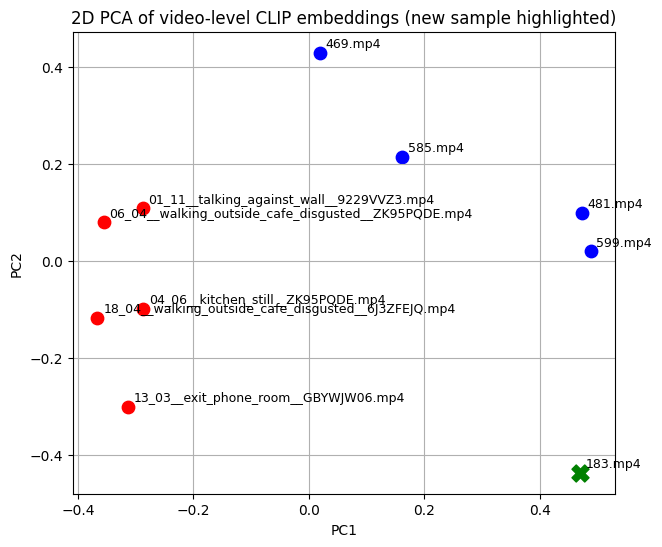

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import os

# --- check enough videos ---
if len(video_embs) >= 2:

    # 2D PCA
    z = PCA(n_components=2).fit_transform(video_embs)

    plt.figure(figsize=(7,6))

    for i, (xi, yi) in enumerate(zip(z, video_y)):
        # reference videos
        if i < len(video_y) - 1:
            color = 'blue' if yi == 0 else 'red'  # REAL=blue, FAKE=red
            marker = 'o'
            # optional: size proportional to few-shot FAKE probability
            size = 80
        else:
            # new sample
            color = 'green'
            marker = 'X'
            size = 150  # larger to highlight

        plt.scatter(xi[0], xi[1], color=color, marker=marker, s=size)
        plt.text(xi[0]+0.01, xi[1]+0.01, os.path.basename(video_names[i]), fontsize=9)

    plt.title("2D PCA of video-level CLIP embeddings (new sample highlighted)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

else:
    print("Not enough videos for PCA visualization.")
